In [1]:
print('hello world')

hello world


In [2]:
import pandas as pd
import random
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
import tkinter as tk
from tkinter import ttk, scrolledtext, messagebox
import threading
import requests
import json
from tkinter import font
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np
from datetime import datetime
import math

ML Accuracy: 0.750
DL Accuracy: 0.770


C:\Users\kapoo\AppData\Local\Temp\ipykernel_6292\2752681162.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_delay = df.groupby(dist_bins)['delay'].mean()


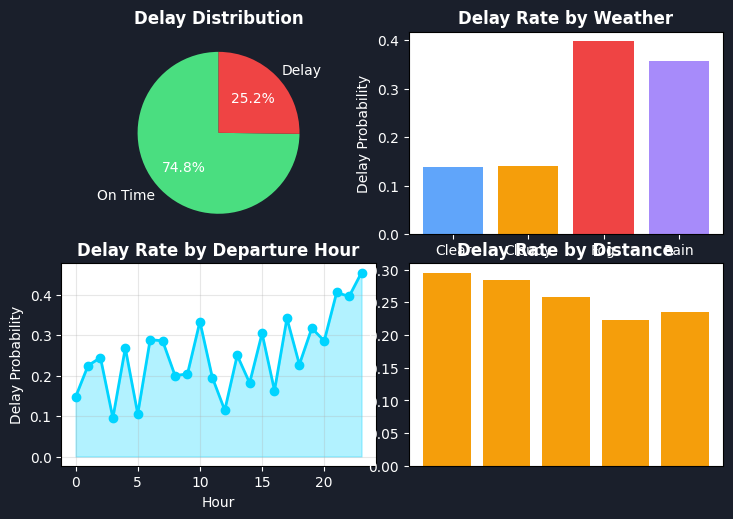

In [3]:
API_KEY = "YOUR_AVIATIONSTACK_API_KEY"

def calculate_distance(source_lat, source_lon, dest_lat, dest_lon):
    R = 6371  # Earth's radius in km
    dlat = math.radians(dest_lat - source_lat)
    dlon = math.radians(dest_lon - source_lon)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(source_lat)) * math.cos(math.radians(dest_lat)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return int(R * c)

# Airport coordinates
AIRPORT_COORDS = {
    "Delhi": (28.5562, 77.1000),
    "Mumbai": (19.0900, 72.8683),
    "Bangalore": (12.9791, 77.5906),
    "Chennai": (12.9842, 80.1699),
    "Kolkata": (22.6522, 88.4467),
    "Hyderabad": (17.2313, 78.4290),
    "Pune": (18.5820, 73.9199)
}

airlines = ["Indigo", "Air India", "SpiceJet", "Vistara", "GoAir"]
airports = list(AIRPORT_COORDS.keys())

# Generate enhanced dataset
data = []
for _ in range(1000):
    airline = random.choice(airlines)
    source = random.choice(airports)
    destination = random.choice(airports)
    while source == destination:
        destination = random.choice(airports)
    
    # Real distance calculation
    src_lat, src_lon = AIRPORT_COORDS[source]
    dst_lat, dst_lon = AIRPORT_COORDS[destination]
    distance = calculate_distance(src_lat, src_lon, dst_lat, dst_lon)
    
    departure_hour = random.randint(0, 23)
    weather = random.choice(["Clear", "Rain", "Fog", "Cloudy"])
    
    # Enhanced delay logic
    delay_prob = 0.1
    if weather in ["Rain", "Fog"] or departure_hour > 20 or distance > 2000:
        delay_prob += 0.3
    if random.random() < delay_prob:
        delay = 1
    else:
        delay = 0
    
    data.append([airline, source, destination, distance, departure_hour, weather, delay])

df = pd.DataFrame(data, columns=["airline", "source", "destination", "distance", "departure_hour", "weather", "delay"])
df.to_csv("flights_enhanced.csv", index=False)

# Load and preprocess data
df = pd.read_csv("flights_enhanced.csv")
X = df.drop("delay", axis=1)
y = df["delay"]

encoders = {}
for col in ["airline", "source", "destination", "weather"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# Train ML model
model_ml = RandomForestClassifier(n_estimators=100, random_state=42)
model_ml.fit(X_train.numpy(), y_train.numpy())
accuracy_ml = model_ml.score(X_test.numpy(), y_test.numpy())

# Neural Network
class FlightModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        return self.out(x)

model_dl = FlightModel(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001, weight_decay=1e-5)

# Train DL model
for epoch in range(100):
    outputs = model_dl(X_train)
    loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    outputs = model_dl(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy_dl = (predicted == y_test).sum().item() / len(y_test)

print(f"ML Accuracy: {accuracy_ml:.3f}")
print(f"DL Accuracy: {accuracy_dl:.3f}")

def get_live_distance(source, destination):
    """Calculate real distance between airports"""
    if source in AIRPORT_COORDS and destination in AIRPORT_COORDS:
        src_lat, src_lon = AIRPORT_COORDS[source]
        dst_lat, dst_lon = AIRPORT_COORDS[destination]
        return calculate_distance(src_lat, src_lon, dst_lat, dst_lon)
    return 1400  # Default distance

def fetch_live_flights(source, destination):
    """Fetch live flight data from AviationStack API"""
    try:
        url = f"http://api.aviationstack.com/v1/flights"
        params = {
            'access_key': API_KEY,
            'dep_iata': source[:3].upper(),  # First 3 letters as IATA
            'arr_iata': destination[:3].upper(),
            'flight_status': 'scheduled'
        }
        response = requests.get(url, params=params)
        if response.status_code == 200:
            data = response.json()
            if data['data']:
                flight = data['data'][0]
                return {
                    'flight_number': flight.get('flight', {}).get('iata', 'N/A'),
                    'airline': flight.get('airline', {}).get('name', 'N/A'),
                    'status': flight.get('flight_status', 'N/A'),
                    'departure_time': flight.get('departure', {}).get('scheduled', 'N/A')
                }
    except:
        pass
    return None

def predict_flight(airline, source, destination, distance, hour, weather):
    try:
        data = pd.DataFrame([[airline, source, destination, distance, hour, weather]],
                           columns=['airline', 'source', 'destination', 'distance', 'departure_hour', 'weather'])

        for col in ["airline", "source", "destination", "weather"]:
            if col in encoders:
                data[col] = encoders[col].transform(data[col])

        data_scaled = scaler.transform(data)
        tensor = torch.tensor(data_scaled, dtype=torch.float32)

        with torch.no_grad():
            output = model_dl(tensor)
            probabilities = torch.softmax(output, dim=1)
            delay_prob = probabilities[0][1].item()
            _, pred = torch.max(output, 1)

        confidence = max(probabilities[0].numpy())
        return "Delay" if pred.item() == 1 else "On Time", delay_prob, confidence
    except:
        return "Error", 0.5, 0.5

class FlightDashboard:
    def __init__(self, root):
        self.root = root
        self.root.title("🚀 Advanced Flight Delay Predictor - Live Dashboard")
        self.root.geometry("1600x1000")
        self.root.configure(bg='#0f1419')
        
        # Custom fonts
        self.title_font = font.Font(family="Arial", size=24, weight="bold")
        self.header_font = font.Font(family="Arial", size=14, weight="bold")
        self.body_font = font.Font(family="Arial", size=11)
        
        self.create_widgets()
        self.load_visualizations()
        self.load_data()
    
    def create_widgets(self):
        # Main container
        main_frame = tk.Frame(self.root, bg='#0f1419')
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Title
        title_frame = tk.Frame(main_frame, bg='#0f1419')
        title_frame.pack(fill=tk.X, pady=(0, 20))
        title_label = tk.Label(title_frame, text="✈️ LIVE FLIGHT DELAY PREDICTION DASHBOARD", 
                              font=self.title_font, fg='#00d4ff', bg='#0f1419')
        title_label.pack()
        
        # Accuracy cards
        acc_frame = tk.Frame(main_frame, bg='#1a1f2b', relief=tk.RAISED, bd=2)
        acc_frame.pack(fill=tk.X, pady=(0, 20))
        tk.Label(acc_frame, text=f"🤖 ML Model: {accuracy_ml:.1%}", 
                font=self.header_font, fg='#4ade80', bg='#1a1f2b').pack(side=tk.LEFT, padx=30, pady=15)
        tk.Label(acc_frame, text=f"🧠 DL Model: {accuracy_dl:.1%}", 
                font=self.header_font, fg='#f59e0b', bg='#1a1f2b').pack(side=tk.LEFT, padx=30, pady=15)
        tk.Label(acc_frame, text=f"📊 Total Records: {len(df):,}", 
                font=self.header_font, fg='#a78bfa', bg='#1a1f2b').pack(side=tk.LEFT, padx=30, pady=15)
        
        # Content frame
        content_frame = tk.Frame(main_frame, bg='#0f1419')
        content_frame.pack(fill=tk.BOTH, expand=True)
        
        # Left panel - Flight selector & Predictor
        left_panel = tk.Frame(content_frame, bg='#1a1f2b', relief=tk.RAISED, bd=3, width=500)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        # Flight selector
        selector_frame = tk.LabelFrame(left_panel, text="🎯 Select Flight Route", 
                                     font=self.header_font, fg='#00d4ff', bg='#1a1f2b')
        selector_frame.pack(fill=tk.X, padx=15, pady=(20, 10))
        
        tk.Label(selector_frame, text="Source:", font=self.body_font, fg='white', bg='#1a1f2b').grid(row=0, column=0, sticky='w', padx=5, pady=5)
        self.source_var = tk.StringVar(value="Delhi")
        source_combo = ttk.Combobox(selector_frame, textvariable=self.source_var, values=airports, 
                                  state="readonly", font=self.body_font, width=15)
        source_combo.grid(row=0, column=1, padx=5, pady=5)
        source_combo.bind('<<ComboboxSelected>>', self.on_route_change)
        
        tk.Label(selector_frame, text="Destination:", font=self.body_font, fg='white', bg='#1a1f2b').grid(row=1, column=0, sticky='w', padx=5, pady=5)
        self.dest_var = tk.StringVar(value="Mumbai")
        dest_combo = ttk.Combobox(selector_frame, textvariable=self.dest_var, values=airports, 
                                state="readonly", font=self.body_font, width=15)
        dest_combo.grid(row=1, column=1, padx=5, pady=5)
        dest_combo.bind('<<ComboboxSelected>>', self.on_route_change)
        
        # Auto-calculated distance
        self.distance_frame = tk.Frame(selector_frame, bg='#1a1f2b')
        self.distance_frame.grid(row=2, column=0, columnspan=2, sticky='w', padx=5, pady=5)
        self.distance_label = tk.Label(self.distance_frame, text="Distance: Calculating...", 
                                     font=self.body_font, fg='#f59e0b', bg='#1a1f2b')
        self.distance_label.pack(side=tk.LEFT)
        
        # Airline selector
        tk.Label(selector_frame, text="Airline:", font=self.body_font, fg='white', bg='#1a1f2b').grid(row=3, column=0, sticky='w', padx=5, pady=5)
        self.airline_var = tk.StringVar(value="Indigo")
        airline_combo = ttk.Combobox(selector_frame, textvariable=self.airline_var, values=airlines, 
                                   state="readonly", font=self.body_font, width=15)
        airline_combo.grid(row=3, column=1, padx=5, pady=5)
        
        # Departure time
        tk.Label(selector_frame, text="Departure (24h):", font=self.body_font, fg='white', bg='#1a1f2b').grid(row=4, column=0, sticky='w', padx=5, pady=5)
        self.hour_var = tk.StringVar(value="14")
        hour_combo = ttk.Combobox(selector_frame, textvariable=self.hour_var, 
                                values=[f"{i:02d}" for i in range(24)], state="readonly", width=15)
        hour_combo.grid(row=4, column=1, padx=5, pady=5)
        
        tk.Label(selector_frame, text="Weather:", font=self.body_font, fg='white', bg='#1a1f2b').grid(row=5, column=0, sticky='w', padx=5, pady=5)
        self.weather_var = tk.StringVar(value="Clear")
        weather_combo = ttk.Combobox(selector_frame, textvariable=self.weather_var, 
                                   values=["Clear", "Rain", "Fog", "Cloudy"], state="readonly", width=15)
        weather_combo.grid(row=5, column=1, padx=5, pady=5)
        
        # Predict button
        predict_btn = tk.Button(selector_frame, text="🔮 PREDICT DELAY", command=self.predict_flight,
                               bg="#00d4ff", fg="black", font=self.header_font, relief=tk.FLAT, pady=8)
        predict_btn.grid(row=6, column=0, columnspan=2, pady=20)
        
        # Live flight info
        self.live_frame = tk.LabelFrame(left_panel, text="🌐 Live Flight Status", 
                                      font=self.header_font, fg='#00ff88', bg='#1a1f2b')
        self.live_frame.pack(fill=tk.X, padx=15, pady=(0, 20))
        self.live_info = tk.Label(self.live_frame, text="Select route to see live flights", 
                                font=self.body_font, fg='#888', bg='#1a1f2b')
        self.live_info.pack(pady=15)
        
        # Prediction result
        self.result_frame = tk.LabelFrame(left_panel, text="📊 Prediction Result", 
                                        font=self.header_font, fg='#4ade80', bg='#1a1f2b')
        self.result_frame.pack(fill=tk.X, padx=15, pady=(0, 20))
        self.result_label = tk.Label(self.result_frame, text="Make a prediction to see results", 
                                   font=self.body_font, fg='#888', bg='#1a1f2b')
        self.result_label.pack(pady=15)
        
        # Right panel - Visualizations & Data
        right_panel = tk.Frame(content_frame, bg='#0f1419')
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        # Charts frame
        charts_frame = tk.LabelFrame(right_panel, text="📈 Analytics Dashboard", 
                                   font=self.header_font, fg='#f59e0b', bg='#1a1f2b')
        charts_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=(0, 10))
        
        self.charts_canvas = tk.Frame(charts_frame, bg='#1a1f2b')
        self.charts_canvas.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Data table frame
        data_frame = tk.LabelFrame(right_panel, text="📋 Recent Flights", 
                                 font=self.header_font, fg='#a78bfa', bg='#1a1f2b')
        data_frame.pack(fill=tk.X, padx=10, pady=(0, 10))
        
        # Treeview
        columns = ("Airline", "Route", "Distance", "Hour", "Weather", "Status")
        self.tree = ttk.Treeview(data_frame, columns=columns, show="headings", height=8)
        for col in columns:
            self.tree.heading(col, text=col)
            self.tree.column(col, width=110, anchor='center')
        
        scrollbar = ttk.Scrollbar(data_frame, orient=tk.VERTICAL, command=self.tree.yview)
        self.tree.configure(yscrollcommand=scrollbar.set)
        self.tree.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=10, pady=10)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y, pady=10)
        
        # Status bar
        self.status_var = tk.StringVar(value="Ready - Select a route to begin")
        status_bar = tk.Label(right_panel, textvariable=self.status_var, relief=tk.SUNKEN, 
                            anchor=tk.W, fg='white', bg='#1a1f2b')
        status_bar.pack(side=tk.BOTTOM, fill=tk.X)
        
        # Initial route calculation
        self.on_route_change()
    
    def on_route_change(self, event=None):
        source = self.source_var.get()
        dest = self.dest_var.get()
        distance = get_live_distance(source, dest)
        self.distance_label.config(text=f"Distance: {distance:,} km", fg='#4ade80')
        self.status_var.set(f"Route updated: {source} → {dest} ({distance:,} km)")
    
    def load_visualizations(self):
        # Delay distribution pie chart
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        fig.patch.set_facecolor('#1a1f2b')
        
        # 1. Delay Distribution
        delay_counts = df['delay'].value_counts()
        colors = ['#4ade80', '#ef4444']
        ax1.pie(delay_counts.values, labels=['On Time', 'Delay'], colors=colors, autopct='%1.1f%%', 
                startangle=90, textprops={'color': 'white', 'fontsize': 10})
        ax1.set_title('Delay Distribution', color='white', fontsize=12, fontweight='bold')
        
        # 2. Weather vs Delay
        weather_delay = df.groupby('weather')['delay'].mean()
        ax2.bar(weather_delay.index, weather_delay.values, color=['#60a5fa', '#f59e0b', '#ef4444', '#a78bfa'])
        ax2.set_title('Delay Rate by Weather', color='white', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Delay Probability', color='white')
        ax2.tick_params(colors='white')
        
        # 3. Hour vs Delay
        hour_delay = df.groupby('departure_hour')['delay'].mean()
        ax3.plot(hour_delay.index, hour_delay.values, marker='o', linewidth=2, color='#00d4ff')
        ax3.fill_between(hour_delay.index, hour_delay.values, alpha=0.3, color='#00d4ff')
        ax3.set_title('Delay Rate by Departure Hour', color='white', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Hour', color='white')
        ax3.set_ylabel('Delay Probability', color='white')
        ax3.tick_params(colors='white')
        ax3.grid(True, alpha=0.3)
        
        # 4. Distance vs Delay
        dist_bins = pd.cut(df['distance'], bins=5)
        dist_delay = df.groupby(dist_bins)['delay'].mean()
        ax4.bar(range(len(dist_delay)), dist_delay.values, color='#f59e0b')
        ax4.set_title('Delay Rate by Distance', color='white', fontsize=12, fontweight='bold')
        ax4.set_xticks([])
        ax4.tick_params(colors='white')
        
        plt.tight_layout()
        
        self.canvas = FigureCanvasTkAgg(fig, self.charts_canvas)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    
    def load_data(self):
        recent_df = df.tail(50).copy()
        recent_df['status'] = recent_df['delay'].map({0: 'On Time', 1: 'Delay'})
        recent_df['route'] = recent_df['source'] + ' → ' + recent_df['destination']
        
        for item in self.tree.get_children():
            self.tree.delete(item)
        
        for _, row in recent_df.iterrows():
            self.tree.insert("", tk.END, values=(
                row['airline'][:10], row['route'][:12], 
                f"{int(row['distance']):,}", row['departure_hour'],
                row['weather'], row['status']
            ))
    
    def predict_flight(self):
        try:
            airline = self.airline_var.get()
            source = self.source_var.get()
            destination = self.dest_var.get()
            distance = get_live_distance(source, destination)
            hour = int(self.hour_var.get())
            weather = self.weather_var.get()
            
            prediction, delay_prob, confidence = predict_flight(airline, source, destination, distance, hour, weather)
            
            # Update result display
            color = "#4ade80" if prediction == "On Time" else "#ef4444"
            prob_text = f"{delay_prob:.1%}"
            
            result_text = f"""
🎯 PREDICTION: **{prediction}**
📊 Delay Probability: {prob_text}
✅ Confidence: {confidence:.1%}
📏 Distance: {distance:,} km
🕒 Departure: {hour}:00
🌤️ Weather: {weather}
✈️  Airline: {airline}
📍 Route: {source} → {destination}
            """
            
            self.result_label.config(text=result_text.strip(), fg=color, justify=tk.LEFT)
            
            # Try to fetch live flight data
            live_data = fetch_live_flights(source, destination)
            if live_data:
                live_text = f"✈️ Live: {live_data['flight_number']} | {live_data['status']}"
                self.live_info.config(text=live_text, fg='#00ff88')
            else:
                self.live_info.config(text="No live flights found", fg='#f59e0b')
            
            self.status_var.set(f"Predicted {prediction} (Delay Prob: {delay_prob:.1%})")
            
        except Exception as e:
            messagebox.showerror("Error", f"Prediction failed: {str(e)}")
            self.status_var.set("Prediction error")

def main():
    root = tk.Tk()
    app = FlightDashboard(root)
    root.mainloop()

if __name__ == "__main__":
    main()